# Y.Afisha Marketing Analytics

## Project Overview

This project analyzes user behavior, sales performance, and marketing efficiency for **Y.Afisha**. The objective is to identify how customers interact with the product, when they begin purchasing, how much value they generate, and which acquisition channels provide the strongest return on marketing investment.

The analysis covers:
- Product usage and user retention
- Time from first visit to first purchase
- Order frequency and Average Order Value (AOV)
- Customer Lifetime Value (LTV)
- Marketing spend and Customer Acquisition Cost (CAC)
- ROI by acquisition source and ROMI by cohort

The core visit and marketing datasets cover **June 2017 through May 2018**.


# Step 1. Load and Prepare the Data

In [89]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
# Load datasets
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

# 1A. Visits Data: Exploration and Cleaning

In [91]:
# Inspect the data 
print('VISITS INFO','\n')
visits.info()
print()
print('VISITS HEAD', '\n')
visits.head(10)

VISITS INFO 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB

VISITS HEAD 



,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168
5,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387
6,desktop,2018-01-30 12:09:00,1,2018-01-30 11:13:00,6661610529277171451
7,touch,2017-11-05 15:15:00,3,2017-11-05 15:14:00,11423865690854540312
8,desktop,2017-07-19 10:44:00,3,2017-07-19 10:41:00,2987360259350925644
9,desktop,2017-11-08 13:43:00,5,2017-11-08 13:42:00,1289240080042562063


The visits dataset contains no missing values. Date columns need to be converted to the appropriate data type, column names should be standardized for easier analysis, duplicates should be checked, and month, week, and day fields should be created for time-based analysis.

In [92]:
# Standardize column names
visits.columns = visits.columns.str.strip().str.lower().str.replace(' ', '_')

visits.head()

,device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


### Convert date columns from `object` to `datetime`

In [93]:
# Convert date columns to datetime
visits['end_ts'] = pd.to_datetime(visits['end_ts'], errors='coerce')
visits['start_ts'] = pd.to_datetime(visits['start_ts'], errors='coerce')


# Check for invalid date conversions
visits[['start_ts','end_ts']].isna().sum()

start_ts    0
end_ts      0
dtype: int64

In [94]:
# Inspect the result
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


In [95]:
# Check for duplicate rows
visits.duplicated().sum()

0

In [96]:
# Create time-period columns for analysis
visits['month'] = visits['start_ts'].dt.to_period('M')
visits['week'] = visits['start_ts'].dt.to_period('W')
visits['day'] = visits['start_ts'].dt.date

In [97]:
# Inspect the result dados
visits.head()

,device,end_ts,source_id,start_ts,uid,month,week,day
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12,2017-12-18/2017-12-24,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02,2018-02-19/2018-02-25,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07,2017-06-26/2017-07-02,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05,2018-05-14/2018-05-20,2018-05-20
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12,2017-12-25/2017-12-31,2017-12-27


# 1B. Orders Data: Exploration and Cleaning

In [98]:
# Inspect the data 
print('ORDERS INFO','\n')
orders.info()
print()
print('ORDERS HEAD', '\n')
orders.head(10)

ORDERS INFO 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB

ORDERS HEAD 



,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
5,2017-06-01 08:43:00,0.18,10402394430196413321
6,2017-06-01 08:54:00,1.83,12464626743129688638
7,2017-06-01 09:22:00,1.22,3644482766749211722
8,2017-06-01 09:22:00,3.30,17542070709969841479
9,2017-06-01 09:23:00,0.37,1074355127080856382


The orders dataset contains no missing values. Date columns need to be converted to the appropriate data type, column names should be standardized for easier analysis, duplicates should be checked, and month, week, and day fields should be created for time-based analysis.

In [99]:
# Standardize column names
orders.columns = orders.columns.str.strip().str.lower().str.replace(' ', '_')

orders.head()

,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [100]:
# Convert date columns to datetime
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'], errors='coerce')


# Check for invalid date conversions
orders[['buy_ts']].isna().sum()

buy_ts    0
dtype: int64

In [101]:
# Inspect the result
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [102]:
# Check for duplicate rows
orders.duplicated().sum()

0

In [103]:
# Create time-period columns for analysis
orders['month'] = orders['buy_ts'].dt.to_period('M')
orders['week'] = orders['buy_ts'].dt.to_period('W')
orders['day'] = orders['buy_ts'].dt.date

In [104]:
# Inspect the result resultado
orders.head()

,buy_ts,revenue,uid,month,week,day
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06,2017-05-29/2017-06-04,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06,2017-05-29/2017-06-04,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06,2017-05-29/2017-06-04,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06,2017-05-29/2017-06-04,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06,2017-05-29/2017-06-04,2017-06-01


# 1C. Marketing Costs Data: Exploration and Cleaning

In [105]:
# Inspect the data 
print('COSTS INFO','\n')
costs.info()
print()
print('COSTS HEAD', '\n')
costs.head(10)

COSTS INFO 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB

COSTS HEAD 



,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08
5,1,2017-06-06,40.39
6,1,2017-06-07,40.59
7,1,2017-06-08,56.63
8,1,2017-06-09,40.16
9,1,2017-06-10,43.24


The marketing costs dataset contains no missing values. The date column needs to be converted to the appropriate data type. The remaining columns are already suitable for analysis. Duplicates should also be checked, and month, week, and day fields should be created for time-based analysis.

In [106]:
# Convert date columns to datetime
costs['dt'] = pd.to_datetime(costs['dt'], errors='coerce')


# Check for invalid date conversions
costs[['dt']].isna().sum()

dt    0
dtype: int64

In [107]:
# Inspect the result
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


In [108]:
# Check for duplicate rows
costs.duplicated().sum()

0

In [109]:
# Create time-period columns for analysis
costs['month'] = costs['dt'].dt.to_period('M')
costs['week'] = costs['dt'].dt.to_period('W')
costs['day'] = costs['dt'].dt.date

In [110]:
# Inspect the result resultado
costs.head()

,source_id,dt,costs,month,week,day
0,1,2017-06-01,75.20,2017-06,2017-05-29/2017-06-04,2017-06-01
1,1,2017-06-02,62.25,2017-06,2017-05-29/2017-06-04,2017-06-02
2,1,2017-06-03,36.53,2017-06,2017-05-29/2017-06-04,2017-06-03
3,1,2017-06-04,55.00,2017-06,2017-05-29/2017-06-04,2017-06-04
4,1,2017-06-05,57.08,2017-06,2017-06-05/2017-06-11,2017-06-05


# Step 2. Build Reports and Calculate Metrics

### 1. Product

## How many people use the product each day, week, and month?

In [111]:
# Calculate DAU
dau = visits.groupby('day')['uid'].nunique()
dau

day
2017-06-01     605
2017-06-02     608
2017-06-03     445
2017-06-04     476
2017-06-05     820
              ... 
2018-05-27     620
2018-05-28    1039
2018-05-29     948
2018-05-30    1289
2018-05-31    1997
Name: uid, Length: 364, dtype: int64

<AxesSubplot:title={'center':'DAU - Usuários Ativos Diários'}, xlabel='day'>

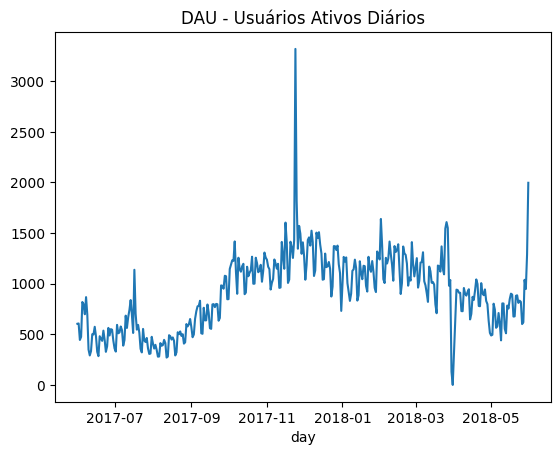

In [112]:
# Inspect the result DAU
dau.plot(title='DAU - Daily Active Users')

In [113]:
# Calculate WAU
wau = visits.groupby('week')['uid'].nunique()
wau

week
2017-05-29/2017-06-04     2021
2017-06-05/2017-06-11     4129
2017-06-12/2017-06-18     2812
2017-06-19/2017-06-25     2878
2017-06-26/2017-07-02     3064
2017-07-03/2017-07-09     3294
2017-07-10/2017-07-16     4355
2017-07-17/2017-07-23     3841
2017-07-24/2017-07-30     2655
2017-07-31/2017-08-06     2364
2017-08-07/2017-08-13     2444
2017-08-14/2017-08-20     2746
2017-08-21/2017-08-27     3116
2017-08-28/2017-09-03     3694
2017-09-04/2017-09-10     4412
2017-09-11/2017-09-17     4319
2017-09-18/2017-09-24     4874
2017-09-25/2017-10-01     6241
2017-10-02/2017-10-08     7612
2017-10-09/2017-10-15     7074
2017-10-16/2017-10-22     7148
2017-10-23/2017-10-29     7401
2017-10-30/2017-11-05     7480
2017-11-06/2017-11-12     7179
2017-11-13/2017-11-19     8117
2017-11-20/2017-11-26    10586
2017-11-27/2017-12-03     8166
2017-12-04/2017-12-10     8407
2017-12-11/2017-12-17     8214
2017-12-18/2017-12-24     7172
2017-12-25/2017-12-31     7774
2018-01-01/2018-01-07     6918
201

<AxesSubplot:title={'center':'WAU - Usuários Ativos Semanais'}, xlabel='week'>

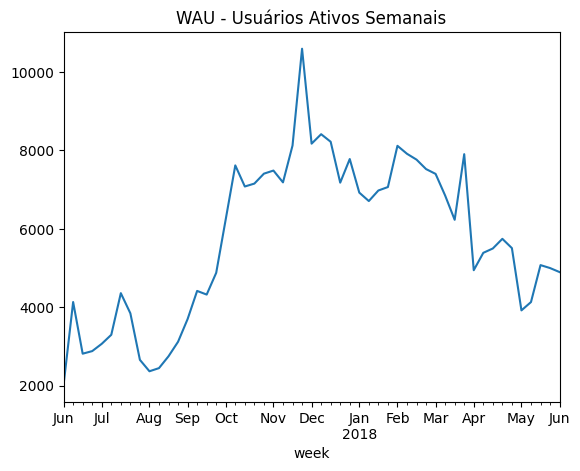

In [114]:
# Inspect the result WAU
wau.plot(title='WAU - Weekly Active Users')

In [115]:
# Calculate MAU
mau = visits.groupby('month')['uid'].nunique()
mau

month
2017-06    13259
2017-07    14183
2017-08    11631
2017-09    18975
2017-10    29692
2017-11    32797
2017-12    31557
2018-01    28716
2018-02    28749
2018-03    27473
2018-04    21008
2018-05    20701
Freq: M, Name: uid, dtype: int64

<AxesSubplot:title={'center':'MAU - Usuários Ativos Mensais'}, xlabel='month'>

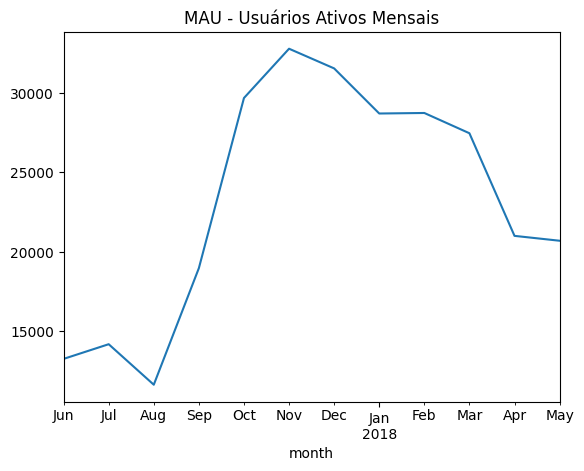

In [116]:
# Inspect the result MAU
mau.plot(title='MAU - Monthly Active Users')

## How many sessions occur each day?

A single user may generate multiple sessions.

In [117]:
# Calculate sessions per day
sessions_per_day = visits.groupby('day').size()
sessions_per_day

day
2017-06-01     664
2017-06-02     658
2017-06-03     477
2017-06-04     510
2017-06-05     893
              ... 
2018-05-27     672
2018-05-28    1156
2018-05-29    1035
2018-05-30    1410
2018-05-31    2256
Length: 364, dtype: int64

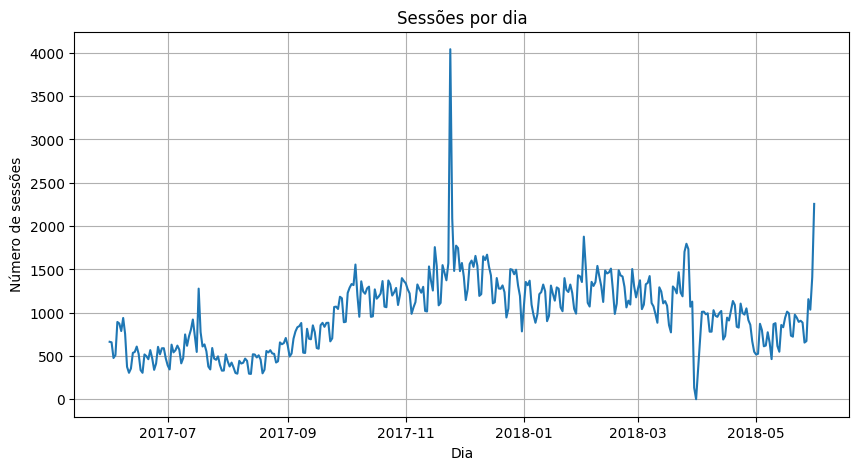

In [118]:
# Plot the result

plt.figure(figsize=(10,5))
sessions_per_day.plot()
plt.title('Sessions per Day')
plt.xlabel('Day')
plt.ylabel('Number of Sessions')
plt.grid()
plt.show()

## How long is each session?

In [119]:
# Calculate session duration
visits['session_duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()

# Convert duration to minutes
visits['session_duration_min'] = visits['session_duration_sec'] / 60

# Keep sessions with positive duration
visits = visits[visits['session_duration_min'] > 0]

In [120]:
# Inspect the result describe
visits['session_duration_min'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    323604.000000
mean         11.902825
std          17.105824
min           0.316667
50%           6.000000
75%          15.000000
90%          28.000000
95%          40.000000
99%          78.000000
max         711.000000
Name: session_duration_min, dtype: float64

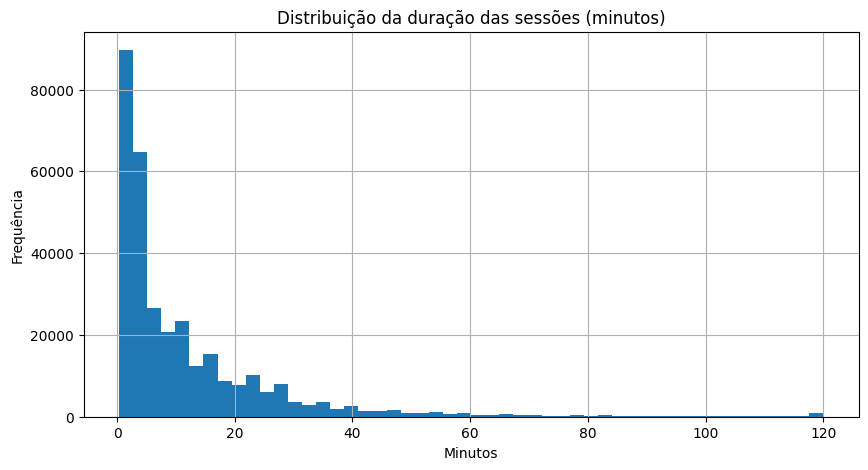

In [121]:
# Plot the session duration distribution
plt.figure(figsize=(10,5))
visits['session_duration_min'].clip(upper=120).hist(bins=50)
plt.title('Session Duration Distribution (Minutes)')
plt.xlabel('Minutes')
plt.ylabel('Frequency')
plt.show()

After removing sessions with non-positive duration, the dataset contains **323,604 valid sessions**.

Key descriptive statistics:
- Average session duration: approximately **11.9 minutes**
- Median session duration: **6 minutes**
- 75th percentile: **15 minutes**
- 90th percentile: **28 minutes**
- 95th percentile: **40 minutes**
- 99th percentile: **78 minutes**
- Maximum observed duration: **711 minutes**

The difference between the mean (11.9 minutes) and the median (6 minutes) indicates a right-skewed distribution. A small number of very long sessions pull the average upward. These unusually long sessions may represent users who left the page open for extended periods.

For this reason, the **median is more representative of typical user behavior** than the mean.


## How often do users return?

In [122]:
# Identify each user's first-visit month
first_visit = visits.groupby('uid')['start_ts'].min().reset_index()
first_visit['cohort_month'] = first_visit['start_ts'].dt.to_period('M')

visits = visits.merge(first_visit[['uid', 'cohort_month']], on='uid')

In [123]:
# Create activity month
visits['activity_month'] = visits['start_ts'].dt.to_period('M')

In [124]:
# Calculate cohort age in months
visits['cohort_index'] = (
    visits['activity_month'] - visits['cohort_month']
).apply(lambda x: x.n)

In [125]:
# Build the cohort table
cohort_data = visits.groupby(['cohort_month', 'cohort_index'])['uid'].nunique().reset_index()

cohort_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='uid'
)

retention = cohort_table.divide(cohort_table[0], axis=0)
retention

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2017-06,1.0,0.075726,0.050989,0.059739,0.065377,0.067480,0.057720,0.056121,0.050989,0.049727,0.038115,0.043921
2017-07,1.0,0.054545,0.050402,0.055645,0.056660,0.046512,0.044059,0.044059,0.037886,0.027315,0.027061,NaN
2017-08,1.0,0.074452,0.060451,0.060451,0.047970,0.041459,0.036249,0.037660,0.027133,0.024745,NaN,NaN
2017-09,1.0,0.083570,0.067769,0.049322,0.038083,0.036959,0.035372,0.022876,0.022744,NaN,NaN,NaN
2017-10,1.0,0.078129,0.050811,0.037811,0.033648,0.031184,0.020775,0.019798,NaN,NaN,NaN,NaN
2017-11,1.0,0.078183,0.042733,0.037824,0.032593,0.021729,0.020602,NaN,NaN,NaN,NaN,NaN
2017-12,1.0,0.054668,0.036518,0.030178,0.019453,0.017716,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,1.0,0.057794,0.037817,0.024352,0.019249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,1.0,0.056561,0.024290,0.019184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


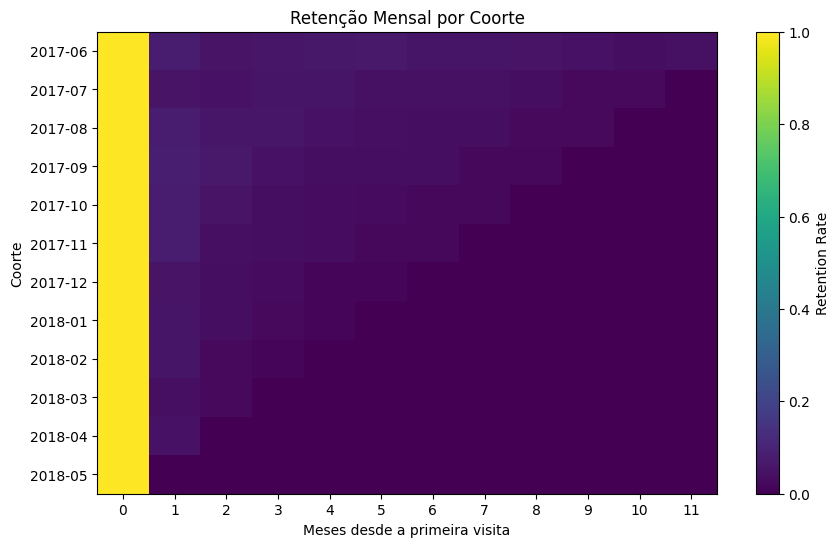

In [126]:
# Plot the result

plt.figure(figsize=(10,6))
plt.imshow(retention.fillna(0).values, aspect='auto')
plt.colorbar(label='Retention Rate')
plt.title('Monthly Retention by Cohort')
plt.xlabel('Months Since First Visit')
plt.ylabel('Cohort')
plt.xticks(range(len(retention.columns)), retention.columns)
plt.yticks(range(len(retention.index)), retention.index)
plt.show()

The cohort analysis shows a substantial decline in active users during the first month after their initial visit. Only a small share of users return in the following month, and retention continues to decline gradually over subsequent months.

This pattern suggests that most users engage with the product only occasionally rather than returning frequently. After several months, retention stabilizes at a low level, indicating a relatively small group of more engaged users.

Overall, the product shows **low short-term retention**, which can directly affect Customer Lifetime Value (LTV) and the efficiency of marketing investments.


### 2. Sales

## When do users start purchasing?

In [127]:
# Identify the first visit date
first_visit = visits.groupby('uid')['start_ts'].min().reset_index()
first_visit.rename(columns={'start_ts': 'first_visit_ts'}, inplace=True)

In [128]:
# Identify the first purchase date
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order.rename(columns={'buy_ts': 'first_order_ts'}, inplace=True)

In [129]:
# Merge first-visit and first-purchase data
conversion = first_visit.merge(first_order, on='uid', how='inner')

In [130]:
# Calculate days from first visit to first purchase
conversion['days_to_purchase'] = (
    conversion['first_order_ts'] - conversion['first_visit_ts']
).dt.days

In [131]:
# Group users by time to first purchase
bins = [-1, 0, 1, 7, 30, 365]
labels = ['0d', '1d', '2-7d', '8-30d', '31+d']

conversion['conversion_group'] = pd.cut(
    conversion['days_to_purchase'],
    bins=bins,
    labels=labels
)

In [132]:
# Review the conversion-time distribution
conversion_distribution = conversion['conversion_group'].value_counts().sort_index()
conversion_distribution

0d       26436
1d         948
2-7d      1967
8-30d     2025
31+d      4510
Name: conversion_group, dtype: int64

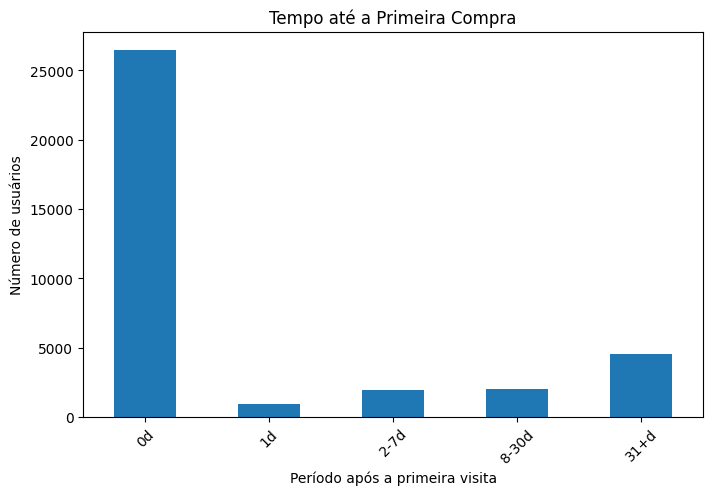

In [133]:
# Plot the result

plt.figure(figsize=(8,5))
conversion_distribution.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Time to First Purchase')
plt.xlabel('Time After First Visit')
plt.ylabel('Number of Users')
plt.show()

The analysis measures the time between each user's first visit and first purchase. A substantial share of conversions occurs on the same day, followed by a sharp decline as the time since the first visit increases.

The probability of conversion decreases over time, indicating that the initial product experience and acquisition campaigns play an important role in driving purchases.

This pattern suggests that strategies focused on the **first user experience and immediate engagement** may improve conversion rates.


## How many orders do customers place during a given period?

In [134]:
# Calculate orders per user by month
orders_per_user_month = (
    orders.groupby(['month', 'uid'])
    .size()
    .reset_index(name='orders_count')
)

orders_per_user_month.head()

,month,uid,orders_count
0,2017-06,1575281904278712,2
1,2017-06,16233238570251706,1
2,2017-06,29085576454138824,1
3,2017-06,31782048561502182,1
4,2017-06,50884319066603964,1


In [135]:
# Calculate average monthly orders per user
avg_orders_month = (
    orders_per_user_month
    .groupby('month')['orders_count']
    .mean()
)

avg_orders_month

month
2017-06    1.163618
2017-07    1.191028
2017-08    1.227582
2017-09    1.231636
2017-10    1.214759
2017-11    1.244557
2017-12    1.258195
2018-01    1.211134
2018-02    1.240254
2018-03    1.273858
2018-04    1.192784
2018-05    1.226298
2018-06    1.000000
Freq: M, Name: orders_count, dtype: float64

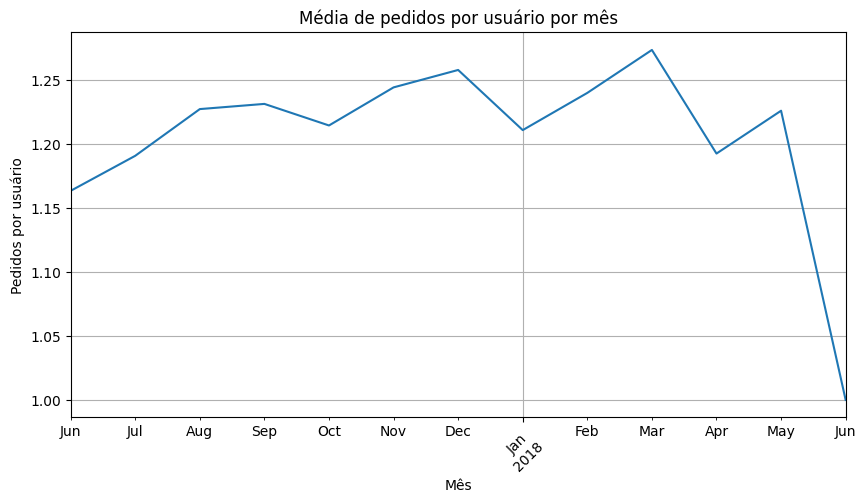

In [136]:
# Plot the result

plt.figure(figsize=(10,5))
avg_orders_month.plot()
plt.title('Average Orders per User per Month')
plt.xlabel('Month')
plt.ylabel('Orders per User')
plt.xticks(rotation=45)
plt.grid()
plt.show()

The average number of orders per user per month remains close to 1 throughout the period, indicating that most customers place only one order per month. Monthly purchase recurrence is relatively low and stable, with only minor variations over time.

In [137]:
# Calculate the monthly median
median_orders_month = (
    orders_per_user_month
    .groupby('month')['orders_count']
    .median()
)

median_orders_month

month
2017-06    1
2017-07    1
2017-08    1
2017-09    1
2017-10    1
2017-11    1
2017-12    1
2018-01    1
2018-02    1
2018-03    1
2018-04    1
2018-05    1
2018-06    1
Freq: M, Name: orders_count, dtype: int64

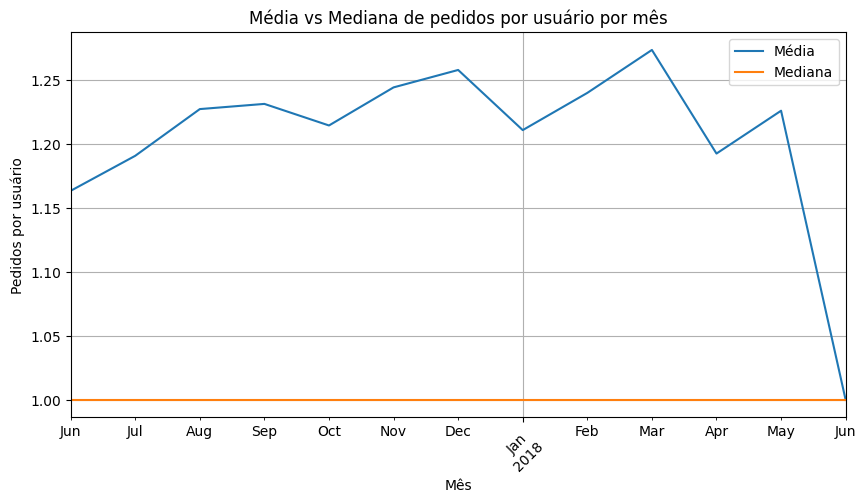

In [138]:
# Compare monthly mean and median

plt.figure(figsize=(10,5))
avg_orders_month.plot(label='Mean')
median_orders_month.plot(label='Median')

plt.title('Mean vs. Median Orders per User per Month')
plt.xlabel('Month')
plt.ylabel('Orders per User')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

The median number of orders per user per month is 1 for most of the period, meaning that at least half of users place only one order per month. A small group of users makes multiple purchases and raises the mean, while the dominant behavior remains a single monthly purchase.

In [139]:
# Calculate the overall order-frequency distribution
orders_per_user_total = (
    orders.groupby('uid')
    .size()
    .reset_index(name='orders_count')
)

orders_distribution = orders_per_user_total['orders_count'].value_counts().sort_index()

orders_distribution

1      30231
2       4395
3       1086
4        375
5        147
       ...  
150        2
183        1
227        1
238        1
239        1
Name: orders_count, Length: 62, dtype: int64

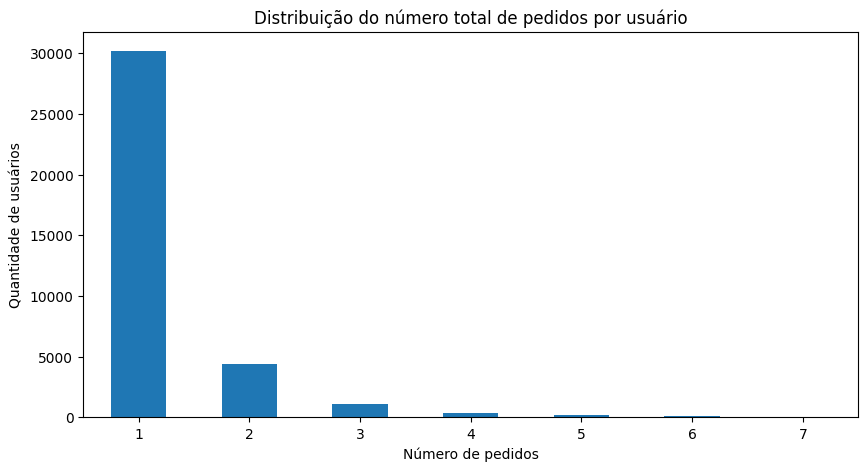

In [140]:
# Plot the result

plt.figure(figsize=(10,5))
orders_distribution.plot(kind='bar')
plt.title('Total Orders per User Distribution')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Users')
plt.xticks(rotation=0)
plt.xlim(-0.5, 6.5)
plt.show()

The overall distribution makes the difference in purchase frequency clearer. Most users purchase only once, and the number of customers declines sharply after the second purchase.

In [141]:
# Customer order frequency by acquisition cohort

# Identify each customer's first-purchase month (acquisition cohort)
first_order_month = orders.groupby('uid')['buy_ts'].min().dt.to_period('M')
first_order_month.name = 'acquisition_month'

# Add cohort information to the orders table
orders_with_cohort = orders.join(first_order_month, on='uid')

# Month of each order
orders_with_cohort['order_month'] = orders_with_cohort['buy_ts'].dt.to_period('M')

# Calculate cohort age in months since the first purchase
orders_with_cohort['cohort_age'] = (orders_with_cohort['order_month'] - orders_with_cohort['acquisition_month']).apply(lambda x: x.n)

# Count total orders by acquisition cohort and cohort age
orders_by_cohort = orders_with_cohort.pivot_table(
    index='acquisition_month',
    columns='cohort_age',
    values='uid',
    aggfunc='count'
)

# Count unique customers in each acquisition cohort
cohort_size = orders_with_cohort.groupby('acquisition_month')['uid'].nunique()

# Calculate average orders per customer by cohort age
avg_orders_pivot = orders_by_cohort.divide(cohort_size, axis=0)


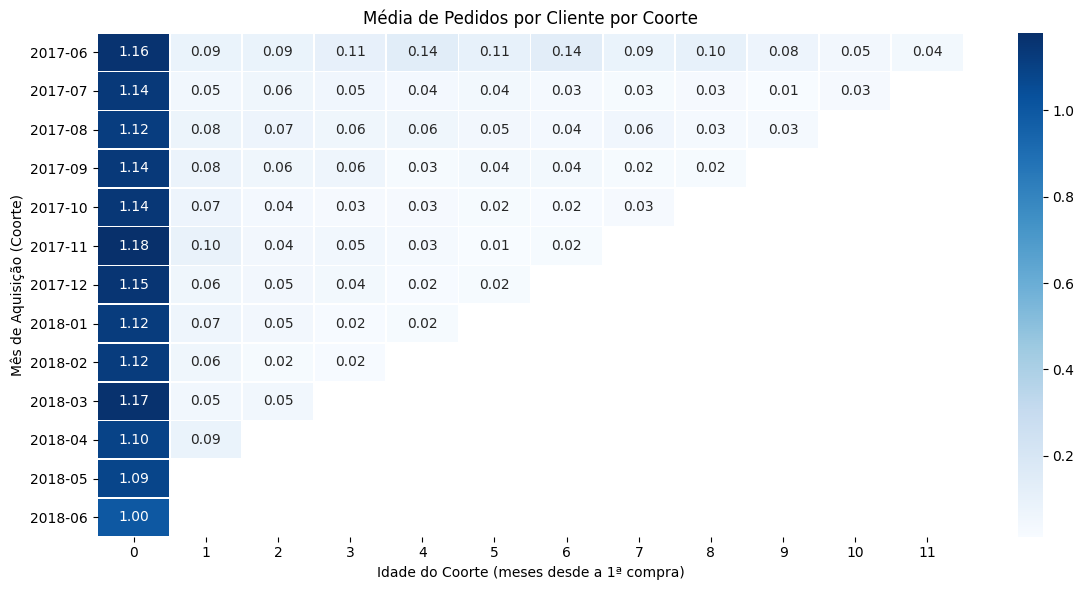

In [142]:
# Convert the index to strings for clearer labels
avg_orders_pivot.index = avg_orders_pivot.index.astype(str)

plt.figure(figsize=(12, 6))

sns.heatmap(
    avg_orders_pivot,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Average Orders per Customer by Cohort")
plt.xlabel("Cohort Age (Months Since First Purchase)")
plt.ylabel("Acquisition Month (Cohort)")
plt.tight_layout()

plt.show()


## What is the Average Order Value (AOV)?

In [143]:
# Calculate overall Average Order Value (AOV)
aov = orders['revenue'].mean()
aov

4.999646930477041

In [144]:
# Calculate monthly Average Order Value (AOV)
aov_month = orders.groupby('month')['revenue'].mean()
aov_month

month
2017-06    4.060106
2017-07    5.306589
2017-08    4.847139
2017-09    5.416448
2017-10    4.928280
2017-11    4.783518
2017-12    5.852139
2018-01    4.112927
2018-02    4.840095
2018-03    5.413930
2018-04    5.150645
2018-05    4.771279
2018-06    3.420000
Freq: M, Name: revenue, dtype: float64

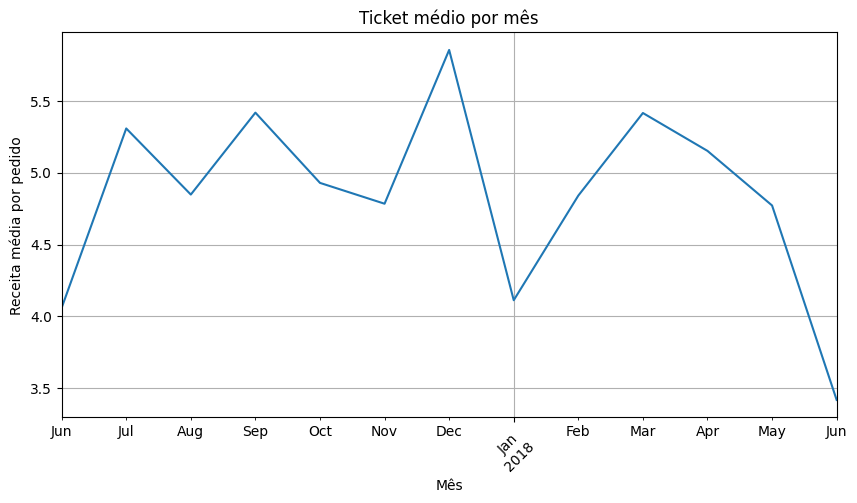

In [145]:
# Plot the result

plt.figure(figsize=(10,5))
aov_month.plot()
plt.title('Average Order Value by Month')
plt.xlabel('Month')
plt.ylabel('Average Revenue per Order')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [146]:
# Calculate the median order value
orders['revenue'].median()

2.5

The monthly Average Order Value shows moderate variation and remains relatively stable at approximately 4 to 6 monetary units per order. December shows a peak that may be related to seasonality, followed by a decline in January. The gap between the mean and median indicates that higher-value orders pull the average upward, suggesting a right-skewed revenue distribution.

## How much revenue does each customer generate for the company (LTV)?

In [147]:
# Identify each user's first-purchase month

first_order = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order['cohort_month'] = first_order['buy_ts'].dt.to_period('M')

In [148]:
# Merge the relevant tables
orders = orders.merge(first_order[['uid', 'cohort_month']], on='uid')
orders['order_month'] = orders['buy_ts'].dt.to_period('M')

In [149]:
# Calculate cohort age in months
orders['cohort_index'] = (
    orders['order_month'] - orders['cohort_month']
).apply(lambda x: x.n)

In [150]:
# Calculate revenue by cohort and cohort age
cohort_revenue = (
    orders.groupby(['cohort_month', 'cohort_index'])['revenue']
    .sum()
    .reset_index()
)

In [151]:
# Build the cohort table pivot
cohort_table = cohort_revenue.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='revenue'
)

In [152]:
# Count unique users in each cohort
cohort_users = orders.groupby('cohort_month')['uid'].nunique()

In [153]:
# Calculate cumulative LTV
ltv = cohort_table.divide(cohort_users, axis=0).cumsum(axis=1)
ltv.round(2)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2017-06,4.72,5.21,5.65,6.60,7.62,8.36,9.31,9.89,10.45,11.05,11.62,11.88
2017-07,6.01,6.35,6.97,7.33,7.50,7.66,7.78,7.92,8.08,8.23,8.39,NaN
2017-08,5.28,5.75,6.21,6.60,7.09,7.38,7.59,7.99,8.28,8.47,NaN,NaN
2017-09,5.64,6.76,7.28,11.26,11.66,12.31,13.01,13.25,13.44,NaN,NaN,NaN
2017-10,5.00,5.54,5.73,5.89,6.04,6.16,6.24,6.36,NaN,NaN,NaN,NaN
2017-11,5.15,5.55,5.75,6.08,6.23,6.28,6.40,NaN,NaN,NaN,NaN,NaN
2017-12,4.74,5.00,5.92,6.99,7.30,7.64,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,4.14,4.43,4.73,4.88,4.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,4.16,4.44,4.51,4.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


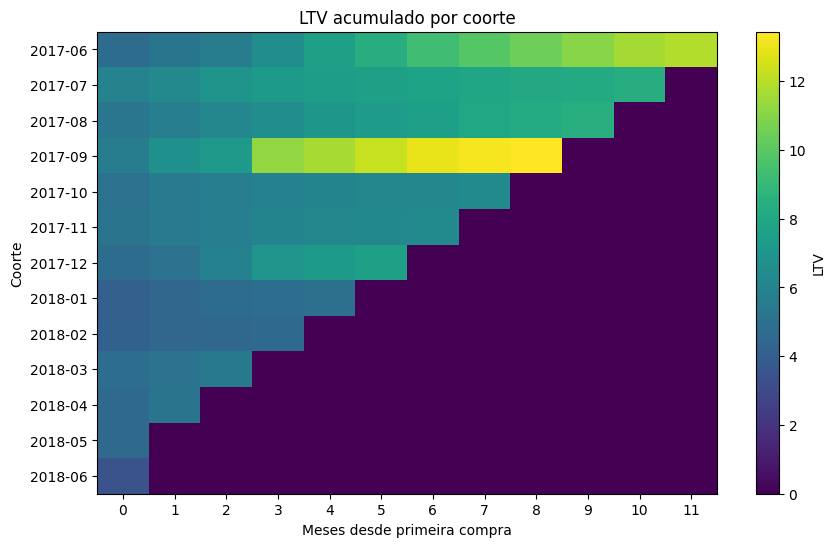

In [154]:
# Plot the result

plt.figure(figsize=(10,6))
plt.imshow(ltv.fillna(0).values, aspect='auto')
plt.colorbar(label='LTV')
plt.title('Cumulative LTV by Cohort')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort')
plt.xticks(range(len(ltv.columns)), ltv.columns)
plt.yticks(range(len(ltv.index)), ltv.index)
plt.show()

The cumulative LTV by cohort shows that most revenue per customer is generated during the first few months after the initial purchase. LTV growth slows over time, indicating limited long-term purchase recurrence. Some cohorts perform slightly better than others, but the overall pattern suggests that customer value depends heavily on early engagement.

### 3. Marketing

## How much was spent on marketing overall, by source, and over time?

In [155]:
# Calculate total marketing spend
total_cost = costs['costs'].sum()
print('Total marketing spend:', '\n')
total_cost

Total marketing spend: 



329131.62

In [156]:
# Calculate marketing spend by source
costs_by_source = (
    costs.groupby('source_id')['costs']
    .sum()
    .sort_values(ascending=False)
)

costs_by_source

source_id
3     141321.63
4      61073.60
5      51757.10
2      42806.04
1      20833.27
10      5822.49
9       5517.49
Name: costs, dtype: float64

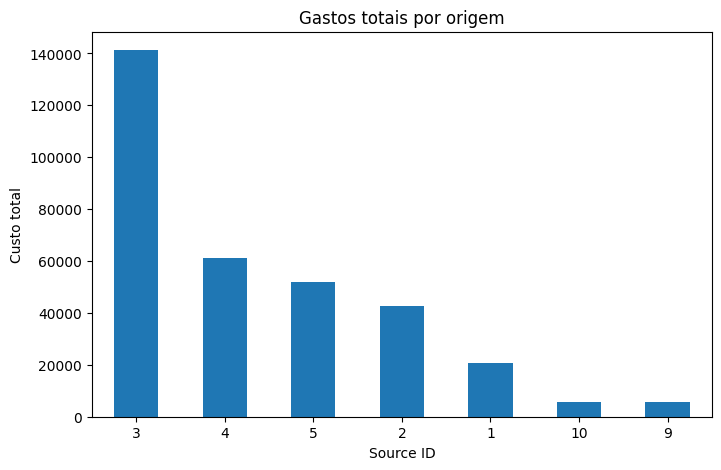

In [157]:
# Plot the result

plt.figure(figsize=(8,5))
costs_by_source.plot(kind='bar')
plt.title('Total Marketing Spend by Source')
plt.xlabel('Source ID')
plt.ylabel('Total Cost')
plt.xticks(rotation=0)
plt.show()

In [158]:
# Calculate marketing spend over time
costs_month = costs.groupby('month')['costs'].sum()
costs_month

month
2017-06    18015.00
2017-07    18240.59
2017-08    14790.54
2017-09    24368.91
2017-10    36322.88
2017-11    37907.88
2017-12    38315.35
2018-01    33518.52
2018-02    32723.03
2018-03    30415.27
2018-04    22289.38
2018-05    22224.27
Freq: M, Name: costs, dtype: float64

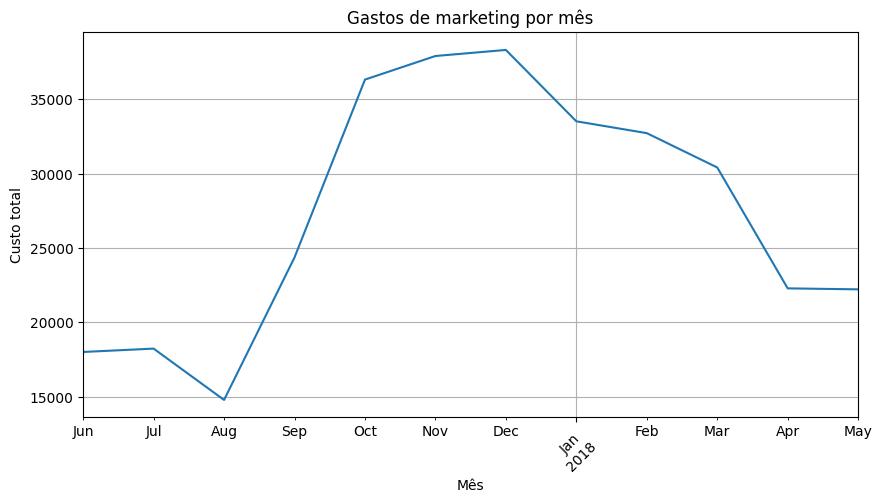

In [159]:
# Plot the result
plt.figure(figsize=(10,5))
costs_month.plot()
plt.title('Marketing Spend by Month')
plt.xlabel('Month')
plt.ylabel('Total Cost')
plt.xticks(rotation=45)
plt.grid()
plt.show()

Marketing investment was not distributed evenly across acquisition sources. Most of the budget was concentrated in **Source 3**, followed by **Sources 4 and 5**, while several other sources received significantly less investment. This concentration makes it important to compare spending with CAC, LTV, and return metrics to evaluate channel efficiency.

## How much did customer acquisition cost for each source?

In [160]:
# Identify each user's first visit
first_visit = (
    visits.sort_values('start_ts')
    .groupby('uid')
    .first()
    .reset_index()
)

In [161]:
# Count acquired users by source
users_by_source = first_visit.groupby('source_id')['uid'].nunique()
users_by_source

source_id
1      9283
2     16401
3     59791
4     65234
5     44160
6         2
7        31
9      5955
10     6194
Name: uid, dtype: int64

In [162]:
# Calculate CAC
cac = costs_by_source / users_by_source
cac

source_id
1     2.244239
2     2.609965
3     2.363594
4     0.936223
5     1.172036
6          NaN
7          NaN
9     0.926531
10    0.940021
dtype: float64

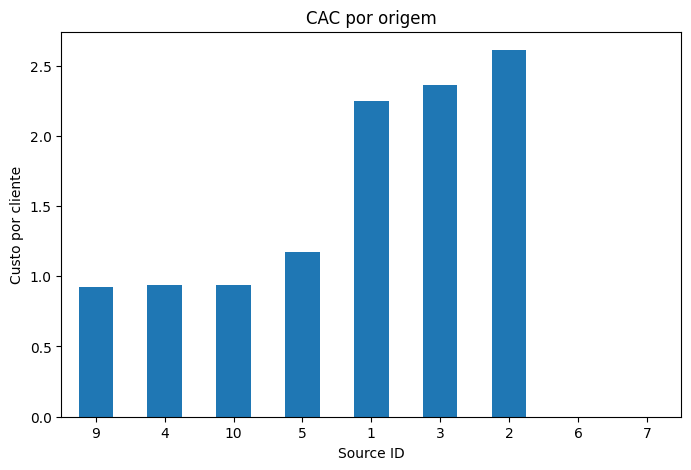

In [163]:
# Plot the result

plt.figure(figsize=(8,5))
cac.sort_values().plot(kind='bar')
plt.title('CAC by Source')
plt.xlabel('Source ID')
plt.ylabel('Cost per Customer')
plt.xticks(rotation=0)
plt.show()

In [164]:
# Identify each user's first-touch acquisition source
first_visit = (
    visits.sort_values('start_ts')
    .groupby('uid')
    .first()
    .reset_index()[['uid', 'source_id']]
)

In [165]:
# Merge the relevant tables
orders_with_source = orders.merge(first_visit, on='uid')

In [166]:
# Calculate total revenue by source
revenue_by_source = (
    orders_with_source
    .groupby('source_id')['revenue']
    .sum()
)

In [167]:
# Count acquired users by source
users_by_source = (
    first_visit.groupby('source_id')['uid']
    .nunique()
)

In [168]:
# Calculate LTV by source
ltv_by_source = revenue_by_source / users_by_source
ltv_by_source

source_id
1     3.289601
2     2.881848
3     0.887452
4     0.852334
5     1.208157
6          NaN
7     0.039355
9     0.965046
10    0.744548
dtype: float64

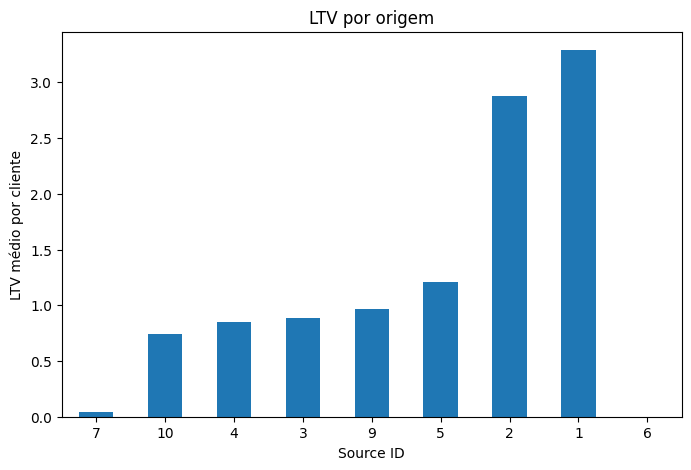

In [169]:
# Plot the result

plt.figure(figsize=(8,5))
ltv_by_source.sort_values().plot(kind='bar')
plt.title('LTV by Source')
plt.xlabel('Source ID')
plt.ylabel('Average LTV per Customer')
plt.xticks(rotation=0)
plt.show()

In [174]:
# Marketing investment payback by acquisition cohort (ROMI)

# Calculate cumulative LTV by cohort
orders['acquisition_month'] = orders.groupby('uid')['buy_ts'].transform('min').dt.to_period('M')
orders['order_month'] = orders['buy_ts'].dt.to_period('M')
orders['cohort_lifetime'] = (orders['order_month'] - orders['acquisition_month']).apply(lambda x: x.n)
cohorts_revenue = orders.groupby(['acquisition_month', 'cohort_lifetime'])['revenue'].sum().reset_index()
cohort_sizes = orders.groupby('acquisition_month')['uid'].nunique().reset_index()
cohort_sizes.columns = ['acquisition_month', 'n_buyers']
cohorts_data = pd.merge(cohorts_revenue, cohort_sizes, on='acquisition_month')
cohorts_data['ltv'] = cohorts_data['revenue'] / cohorts_data['n_buyers']
ltv_pivot = cohorts_data.pivot_table(index='acquisition_month', columns='cohort_lifetime', values='ltv').cumsum(axis=1)

# Calculate CAC by acquisition cohort
costs['month'] = costs['dt'].dt.to_period('M')
first_orders = orders.sort_values('buy_ts').drop_duplicates('uid')
first_orders['acquisition_month'] = first_orders['buy_ts'].dt.to_period('M')
n_buyers_by_cohort = first_orders.groupby('acquisition_month')['uid'].nunique().reset_index()
n_buyers_by_cohort.columns = ['month', 'n_buyers']
costs_by_cohort = costs.groupby('month')['costs'].sum().reset_index()
cac_by_cohort = pd.merge(costs_by_cohort, n_buyers_by_cohort, on='month')
cac_by_cohort['cac'] = cac_by_cohort['costs'] / cac_by_cohort['n_buyers']
cac_by_cohort = cac_by_cohort[['month', 'cac']]
cac_by_cohort.columns = ['acquisition_month', 'cac']

# Calculate ROMI = (LTV - CAC) / CAC
report = pd.merge(ltv_pivot.reset_index(), cac_by_cohort, on='acquisition_month')
report = report.set_index('acquisition_month')

cac_values = report['cac']
ltv_values = report.drop(columns=['cac'])
romi_pivot = ltv_values.subtract(cac_values, axis=0).divide(cac_values, axis=0)


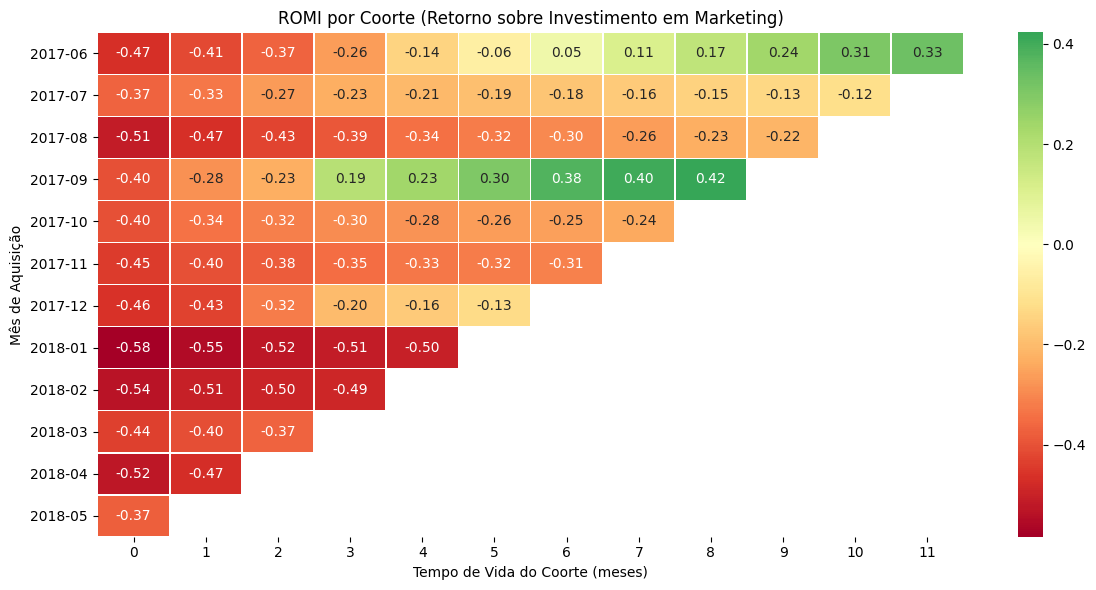

In [175]:
# Convert the index to strings for clearer labels
romi_pivot.index = romi_pivot.index.astype(str)

plt.figure(figsize=(12, 6))

sns.heatmap(
    romi_pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,           # Use zero as the neutral point
    linewidths=0.5
)

plt.title("ROMI by Cohort (Return on Marketing Investment)")
plt.xlabel("Cohort Lifetime (Months)")
plt.ylabel("Acquisition Month")
plt.tight_layout()

plt.show()


## Did the marketing investments pay off? (ROI)

In [171]:
# Align source indices and calculate ROI
roi_by_source = (
    (revenue_by_source - costs_by_source) / costs_by_source
)
roi_by_source

source_id
1     0.465798
2     0.104171
3    -0.624533
4    -0.089604
5     0.030820
7          NaN
9     0.041570
10   -0.207945
dtype: float64

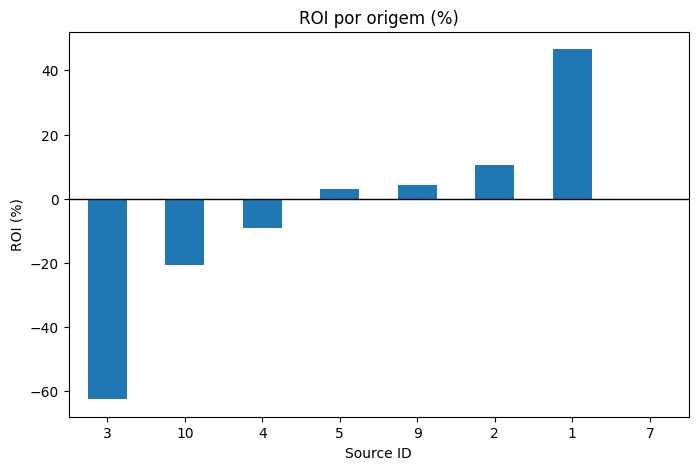

In [172]:
# Plot ROI by source
roi_percent = roi_by_source * 100

plt.figure(figsize=(8,5))
roi_percent.sort_values().plot(kind='bar')

plt.title('ROI by Source (%)')
plt.xlabel('Source ID')
plt.ylabel('ROI (%)')

plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=0)

plt.show()

Marketing investments were only partially effective. Some acquisition sources generated positive ROI and were profitable, while others produced negative returns, indicating inefficient budget allocation. The results support reallocating marketing spend toward the channels with stronger unit economics and returns.

# Step 3. Conclusions and Marketing Recommendations

## Overall Analysis

User behavior indicates **low retention over time**. Most revenue is generated during the first few months after acquisition, and monthly purchase frequency remains close to one order per user.

Average Order Value remains relatively stable, suggesting that revenue growth depends more on acquiring and retaining customers than on increasing the average value of each purchase.

The marketing analysis focuses on three core metrics: **CAC, LTV, and ROI**. Some acquisition sources generated negative ROI, meaning the investment was not fully recovered, while others generated positive returns.

## Strategic Recommendation

Marketing budget should be prioritized toward channels with **positive ROI and CAC below LTV**. A conservative operating target is to keep acquisition cost at no more than approximately **70% of LTV**, leaving room for contribution margin and marketing risk.
